### Visualisations of BioGeoPhysical Parameters for WorldPeatland

This notebook will help you explore the vegetation BioGeoPhysical Parameters produced under the WorldPeatland projects for the different test sites.

1. Pick a site 
2. Pick lat and lon point location within the test site AOI, can get lat and lon from QGIS or using this website https://geojson.io/#map=2/0/20
3. Restart and run all kernels 

Graphs are interactive you can zoom into the years 

!!! Important to not edit the content of the sells !!!

In [1]:
import xarray as xr
import numpy as np
from osgeo import ogr, osr
import rioxarray
from glob import glob
from datetime import datetime,timedelta
import matplotlib.pylab as plt
import matplotlib
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
from matplotlib.dates import MonthLocator, YearLocator
from pyproj import Transformer
matplotlib.use('nbAgg')
import pandas as pd
from rasterstats import zonal_stats, gen_zonal_stats
from tqdm import *
from decimal import *
from matplotlib.patches import Polygon

import fiona
import rasterio
import rasterio.plot
import matplotlib as mpl

import sys
sys.path.insert(0,'/workspace/WorldPeatland/code/')
from gdal_sheep import *
from save_xarray_to_gtiff import *
import matplotlib.dates as mdates

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

/tmp/ipykernel_1838973/3777615979.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
def format_e(n):
    a = '%E' % n
    return a.split('E')[0].rstrip('0').rstrip('.') + 'E' + a.split('E')[1]

## INPUT from USER
### Site Name 

In [4]:
site='CentralKalimantan'

# Fire spot
lat, lon = -2.62085475, 113.89497373

# pristine peat 
lat, lon = -2.61127816, 113.89718371

lat, lon = -2.37940937, 113.80658408
# Pick a year to observe the anomalies and stats better
year = 2016

### RUN all cells, DO NOT change any cell content

### Utils functions

In [5]:
path = f'/wp_data/sites/{site}/MODIS'

In [6]:
def transform_coordinates(lon, lat, source_crs, target_crs):
    """
    Transforms coordinates from a source CRS to a target CRS.
    
    Parameters:
        lon (float): Longitude of the point.
        lat (float): Latitude of the point.
        source_crs (str): Source coordinate reference system in PROJ string format.
        target_crs (str): Target coordinate reference system in PROJ string format.
    
    Returns:
        tuple: Transformed coordinates (x, y).
    """
    transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)
    return x, y

source_crs = "+proj=longlat +datum=WGS84 +no_defs"
target_crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +R=6371007.181 +units=m +no_defs"


In [7]:
def gdal_dt_doy(e, time):
    
    '''
    gdal_dt function will open the tif file as an osegeo gdal dataset 
    
    INPUTS:
        - e (str or tiff) - path the tiff file or the gdal dataset you want to 
            open and save its datetimes
        - time (string) - check how the time variable is written in the tiff metadata
    Outputs:
        - arr (np.array) - return arr of the gdal dataset
        - dts (list) - list of the datetimes 
        - saved_opn (osegeo gdal dataset) - saved dataset for its srs 
    '''
    
    # Create an empty list to store the datatimes 
    dts = []
    doys = []
    
    # Check if the input is a str which would be the tif file 
    # otherwise it is already an opened gdal dataset 
    if type(e) == str:
        # open the Dataset
        opn = gdal.Open(e)
    else:
        opn = e
        
    for i in range(1,opn.RasterCount + 1):
            
        rst = opn.GetRasterBand(i)
        meta = rst.GetMetadata()
        
        # the time data
        x = meta[time]
        # also check the metadata to see how is the format of datetime data
        dt_format = '%j'
        t = dt.strptime(x, dt_format)
            
        # append it to the list
        dts.append(t)
        
        # Calculate the day of the year (DOY) and append it to the list
        doy = t.timetuple().tm_yday
        doys.append(doy)
                        
    # save the last osegeodataset for its srs
    saved_opn = opn
        
    # open the array
    arr = opn.ReadAsArray()
    
    return arr, dts, saved_opn, doys

In [8]:
# Get the coordinates in sinusoidal x and y 
x, y = transform_coordinates(lon, lat, source_crs, target_crs)

## LST

In [9]:
# LST DAY linear.smoothn.descaled
fpath = path + '/timeSeries/MYD11A1.061._LST_Day_1km.linear.smoothn.0.5.descaled.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstDay = create_xarr(opn, 'LST', arr, dts)

# LST DAY detrended
fpath = path + '/timeSeries/MYD11A1.061._LST_Day_1km.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstDayDetrended = create_xarr(opn, 'LST', arr, dts)

# LST NIGHT linear.smoothn.descaled
fpath = path + '/timeSeries/MYD11A1.061._LST_Night_1km.linear.smoothn.0.5.descaled.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstNight = create_xarr(opn, 'LST', arr, dts)

# LST NIGHT detrended
fpath = path + '/timeSeries/MYD11A1.061._LST_Night_1km.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstNightDetrended = create_xarr(opn, 'LST', arr, dts)

# LST DAY climatology mean
fpath = path + "/timeSeries/stats/_LST_Day_1km_climatology_mean.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_lstDay_mean = create_xarr(saved_opn, '_LST_Day_1km', arr, doys)

# LST DAY climatology standard deviation 
fpath = path + "/timeSeries/stats/_LST_Day_1km_climatology_std.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_lstDay_std = create_xarr(saved_opn, '_LST_Day_1km', arr, doys)


# LST DAY anomalies
fpath = path + "/timeSeries/stats/_LST_Day_1km_anomalies.tif"
arr, dts, saved_opn = gdal_dt(fpath)
xr_lstDay_anomalies = create_xarr(saved_opn, '_LST_Day_1km', arr, dts)

In [10]:
# Actual smoothened Observations of LSTs
# Difference between day and night LST 
xr_lstDay['dif_LST'] = xr_lstDay['LST'] - xr_lstNight['LST']

# Actual smoothened Observations of LSTs
# Difference between day and night LST 
xr_lstDayDetrended['dif_LST_detrended'] = xr_lstDayDetrended['LST'] - xr_lstNightDetrended['LST']

<IPython.core.display.Javascript object>


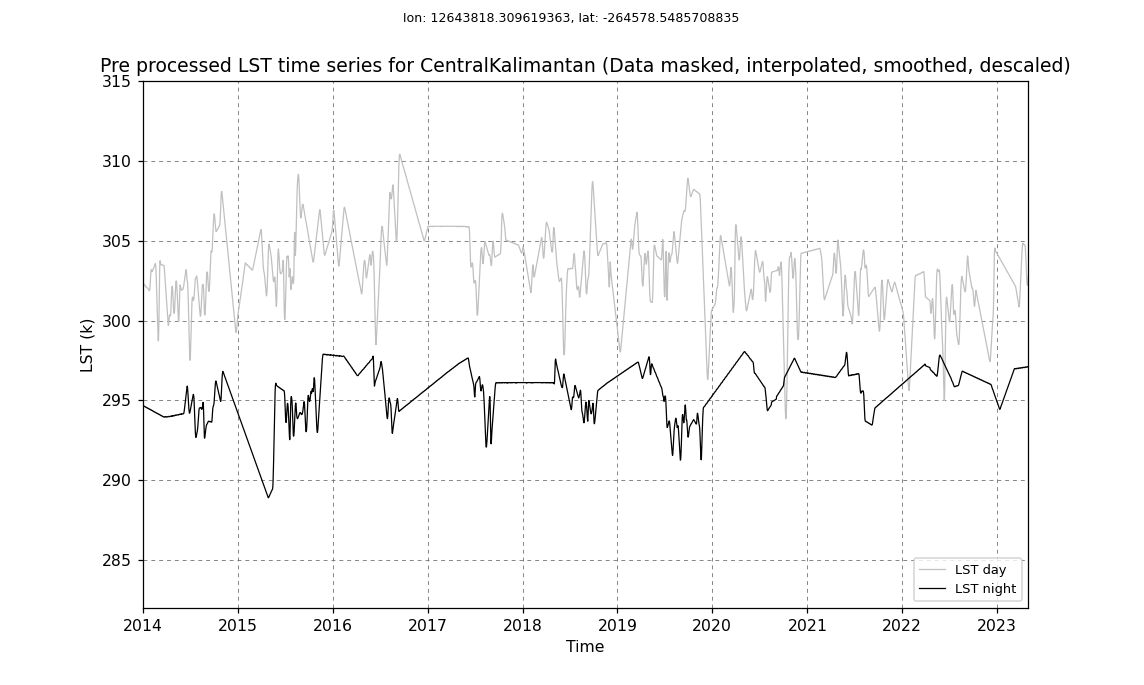

In [28]:
fig, ax = plt.subplots()

ax.plot(xr_lstDay['LST'].time.values, 
        xr_lstDay['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='silver', label="LST day", linewidth=0.8)

ax.plot(xr_lstNight['LST'].time.values, 
        xr_lstNight['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='black', label="LST night", linewidth=0.8)

ax.set_title(f'Pre processed LST time series for {site} (Data masked, interpolated, smoothed, descaled)')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LST (k)')

ax.set_ylim(282, 315)
ax.set_xlim([datetime(2014, 1, 1), datetime(2023, 5, 1)])
plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='lower right', fontsize='small')

# fig.savefig(f'{site}.lst.obs.png', dpi=300)

plt.show()

<IPython.core.display.Javascript object>


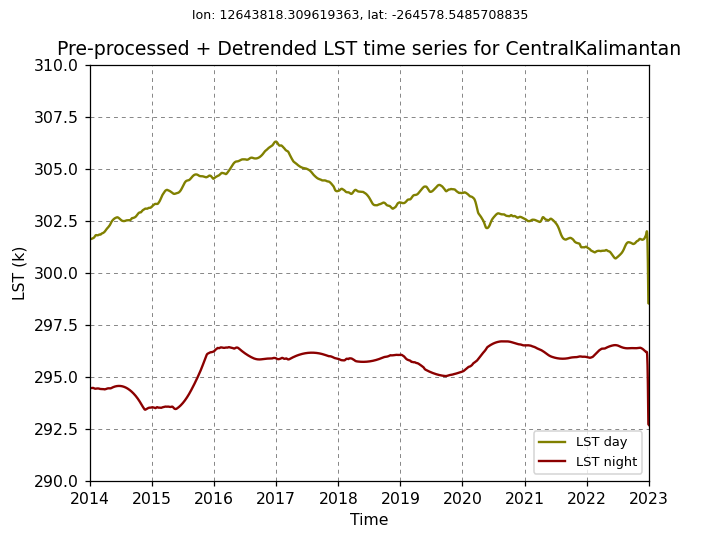

In [12]:
fig, ax = plt.subplots()

ax.plot(xr_lstDayDetrended['LST'].time.values, 
        xr_lstDayDetrended['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='olive', label="LST day")

ax.plot(xr_lstNightDetrended['LST'].time.values, 
        xr_lstNightDetrended['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='darkred', label="LST night")

ax.set_title(f'Pre-processed + Detrended LST time series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LST (k)')

ax.set_ylim(290, 310)
ax.set_xlim([datetime(2014, 1, 1), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='lower right', fontsize='small')
# fig.savefig(f'{site}.lst.detrended.png', dpi=300)
plt.show()

<IPython.core.display.Javascript object>


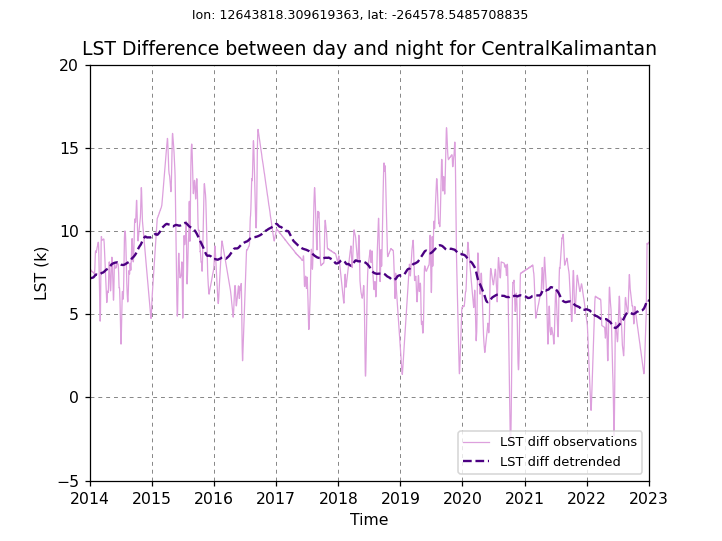

In [13]:
fig, ax = plt.subplots()

ax.plot(xr_lstDay['dif_LST'].time.values, 
        xr_lstDay['dif_LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='plum', label="LST diff observations", linewidth=0.8)

ax.plot(xr_lstDayDetrended['dif_LST_detrended'].time.values, 
        xr_lstDayDetrended['dif_LST_detrended'].sel(latitude=y, longitude=x, method='nearest').data,
       color='indigo', label="LST diff detrended",linestyle='--')

ax.set_title(f'LST Difference between day and night for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LST (k)')

ax.set_ylim(-5,20)
ax.set_xlim([datetime(2014, 1, 1), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='lower right', fontsize='small')
# fig.savefig(f'{site}.lst.diff.png', dpi=300)
plt.show()

<IPython.core.display.Javascript object>


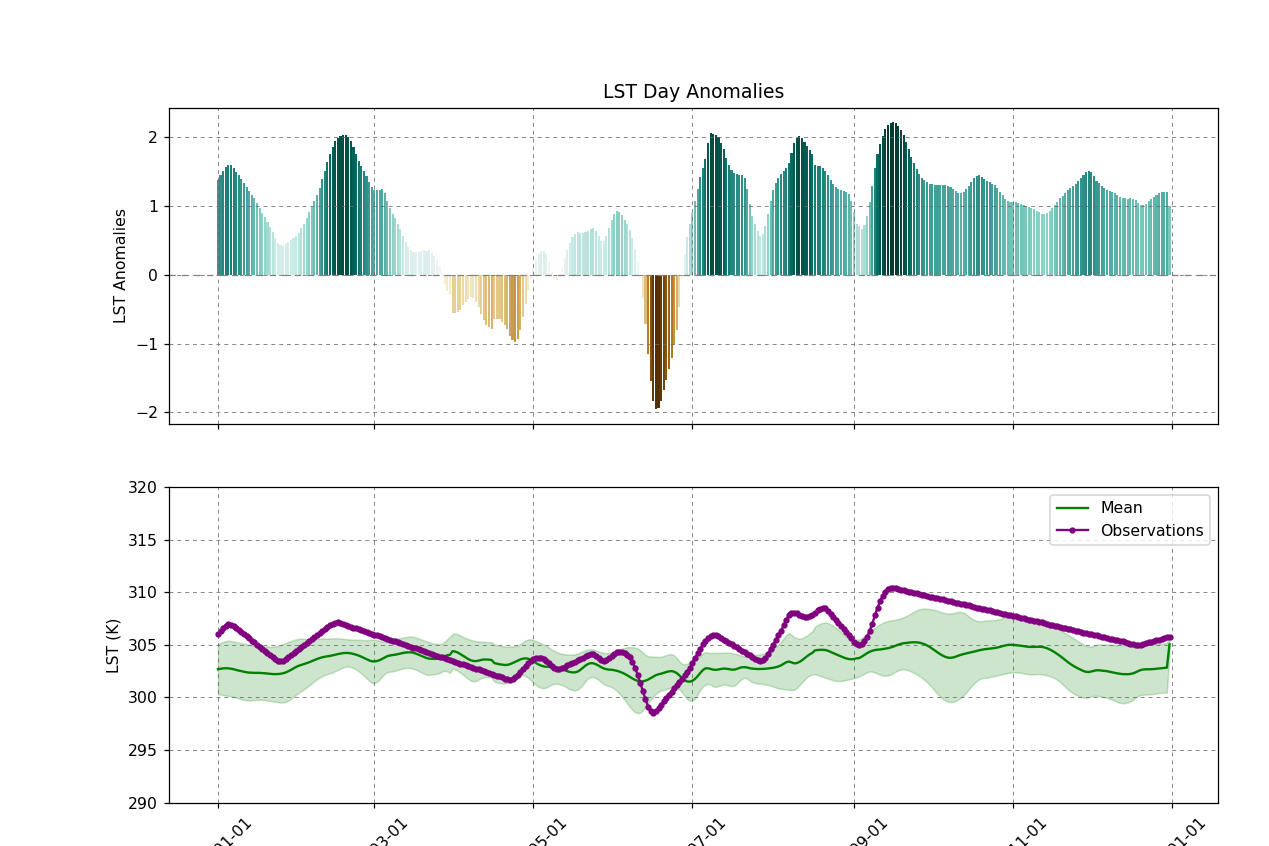

In [14]:
# Get anomalies values for the selected year and the picked lat, lon
data = xr_lstDay_anomalies.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))\
                .sel(longitude=x, latitude=y, method='nearest')
anomalies = data._LST_Day_1km.values

# Dates
dates = data.time.values

# Get observation values for the selected year and the picked lat, lon
data = xr_lstDay.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))\
                .sel(longitude=x, latitude=y, method='nearest')
obs = data.LST.values

# Get mean doy
data = xr_lstDay_mean.sel(longitude=x, latitude=y, method='nearest')
mean = data._LST_Day_1km.values

# Get std doy
data = xr_lstDay_std.sel(longitude=x, latitude=y, method='nearest')
std = data._LST_Day_1km.values

# Compute upper and lower bounds for shaded error region
upper_bound = mean + std
lower_bound = mean - std

# Create figure and subplots
fig, (ax, ox) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Normalize data for colormap
norm = Normalize(vmin=anomalies.min(), vmax=anomalies.max())
cmap = plt.get_cmap('BrBG')
colors = [cmap(norm(value)) for value in anomalies]

# Plot anomalies as bar plot
ax.bar(dates, anomalies, color=colors)
ax.axhline(y=0., color='gray', linestyle=(0, (5, 5)), linewidth=0.8)
ax.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.set_ylabel('LST Anomalies')
ax.set_title('LST Day Anomalies')

# Plot mean, observations, and standard deviation range
ox.plot(dates, mean, color='green', label='Mean')
ox.plot(dates, obs, label='Observations', color="purple", marker='.')
ox.fill_between(dates, lower_bound, upper_bound, alpha=0.2, color='green', interpolate=True)

# Formatting
ox.set_xlabel("Dates")
ox.set_ylabel("LST (K)")
ox.set_ylim(290, 320)
ox.legend()
ox.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)

plt.show()

In [15]:
date_t = a = b = c = ds_p = ds_n = xr_std = xr_mean = ds_sigma_p= xr_anomalies = xr_point = None

## Vegetation

### LAI

In [16]:
# LAI linear.smoothn.descaled
fpath = path + '/timeSeries/MCD15A3H.061._Lai_500m.linear.smoothn.0.5.descaled.tif'
arr, dts_obs, opn = gdal_dt(fpath)
xr_lai = create_xarr(opn, 'lai', arr, dts_obs)

# LAI detrended
fpath = path + '/timeSeries/MCD15A3H.061._Lai_500m.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_laiDetrended = create_xarr(opn, 'lai', arr, dts)

# LAI climatology mean
fpath = path + "/timeSeries/stats/_Lai_500m_climatology_mean.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_mean = create_xarr(saved_opn, '_Lai_500m', arr, doys)

# LAI climatology standard deviation 
fpath = path + "/timeSeries/stats/_Lai_500m_climatology_std.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_std = create_xarr(saved_opn, '_Lai_500m', arr, doys)

# LAI anomalies
fpath = path + "/timeSeries/stats/_Lai_500m_anomalies.tif"
arr, dts, saved_opn = gdal_dt(fpath)
xr_anomalies = create_xarr(saved_opn, '_Lai_500m', arr, dts)

<IPython.core.display.Javascript object>


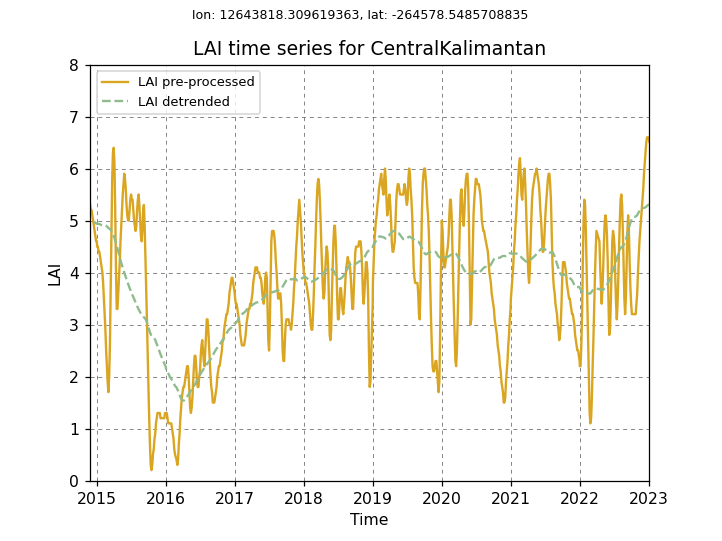

In [17]:
fig, ax = plt.subplots()

ax.plot(xr_lai['lai'].time.values, 
        xr_lai['lai'].sel(latitude=y, longitude=x, method='nearest').data,
       color='goldenrod', label="LAI pre-processed")

ax.plot(xr_laiDetrended['lai'].time.values, 
        xr_laiDetrended['lai'].sel(latitude=y, longitude=x, method='nearest').data,
       color='darkseagreen', label="LAI detrended",linestyle='--')

ax.set_title(f'LAI time series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LAI')

ax.set_ylim(0,8)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='upper left', fontsize='small')
# fig.savefig(f'{site}.lai.png', dpi=300)
plt.show()

In [18]:
# 1. raw data 
fpath = glob(f'/wp_data/sites/{site}/MODIS/MCD15A3H.061/*/Lai_500m/Lai_500m.vrt')[0]
data = rioxarray.open_rasterio(fpath)  # xarray.core.dataarray.DataArray
data_point = data.sel(x=x, y=y, method='nearest').values  # select the data for the selected point
data_point = data_point.astype(float)
data_point[data_point == 255] = np.nan 
data_point = data_point*0.1 

# 2. LAI masked + linear interpolation
fpath = glob(path + f'/MCD15A3H.061/*/Lai_500m/interpolated/MCD15A3H.061._Lai_500m.linear.tif')[0]
arr, dts, opn = gdal_dt(fpath)
xr_interpolated = create_xarr(opn, 'lai', arr, dts)
xr_interpolated = xr_interpolated * 0.1

xr_point = xr_interpolated.sel(longitude=x, latitude=y, method='nearest')

inter_point = xr_point.lai.values

# 3. LAI smoothed
xr_point = xr_lai.sel(longitude=x, latitude=y, method='nearest')

smooth_point = xr_point.lai.values 
time = xr_point.time.values

<IPython.core.display.Javascript object>


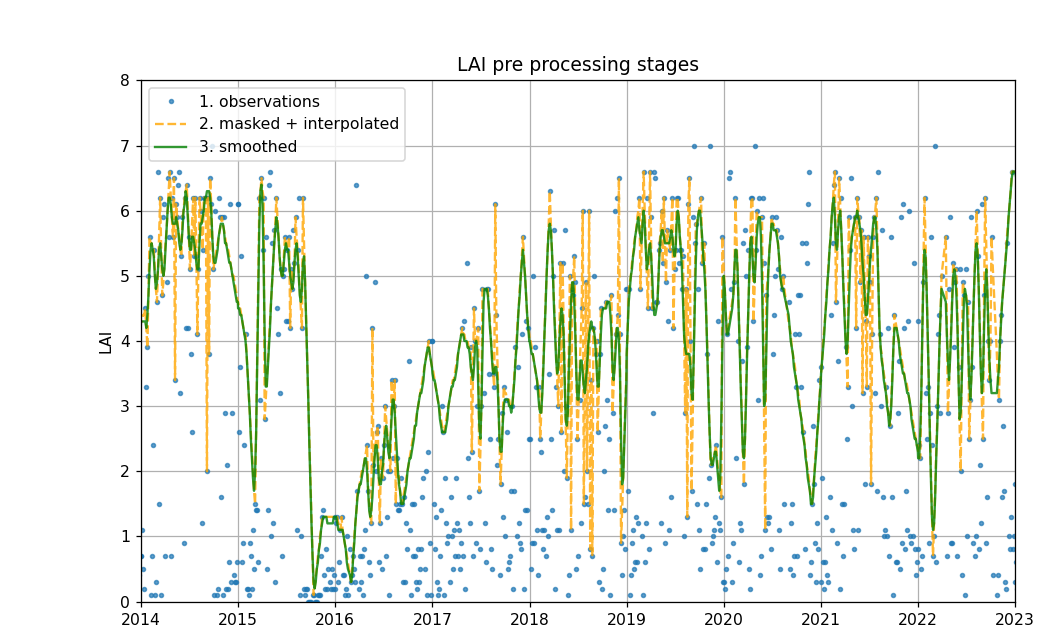

In [19]:
plt.figure(figsize=(10, 6))

# Plot each series
plt.plot(time, data_point, label='1. observations', marker='.', linestyle='', markersize=5, alpha=0.7)
plt.plot(time, inter_point, label='2. masked + interpolated', linestyle='--', color='orange', alpha=0.8)
plt.plot(time, smooth_point, label='3. smoothed', linestyle='-', color='green', alpha=0.8)


xlim_start = np.datetime64('2014-01-01')
xlim_end = np.datetime64('2023-01-01')

# Add titles and labels
plt.title('LAI pre processing stages')
plt.xlabel('Time')
plt.ylabel('LAI')
plt.legend()
plt.grid(True)

# Set x-axis limits
plt.xlim(xlim_start, xlim_end)
plt.ylim(0, 8 )

# Show the plot
plt.show()

<IPython.core.display.Javascript object>


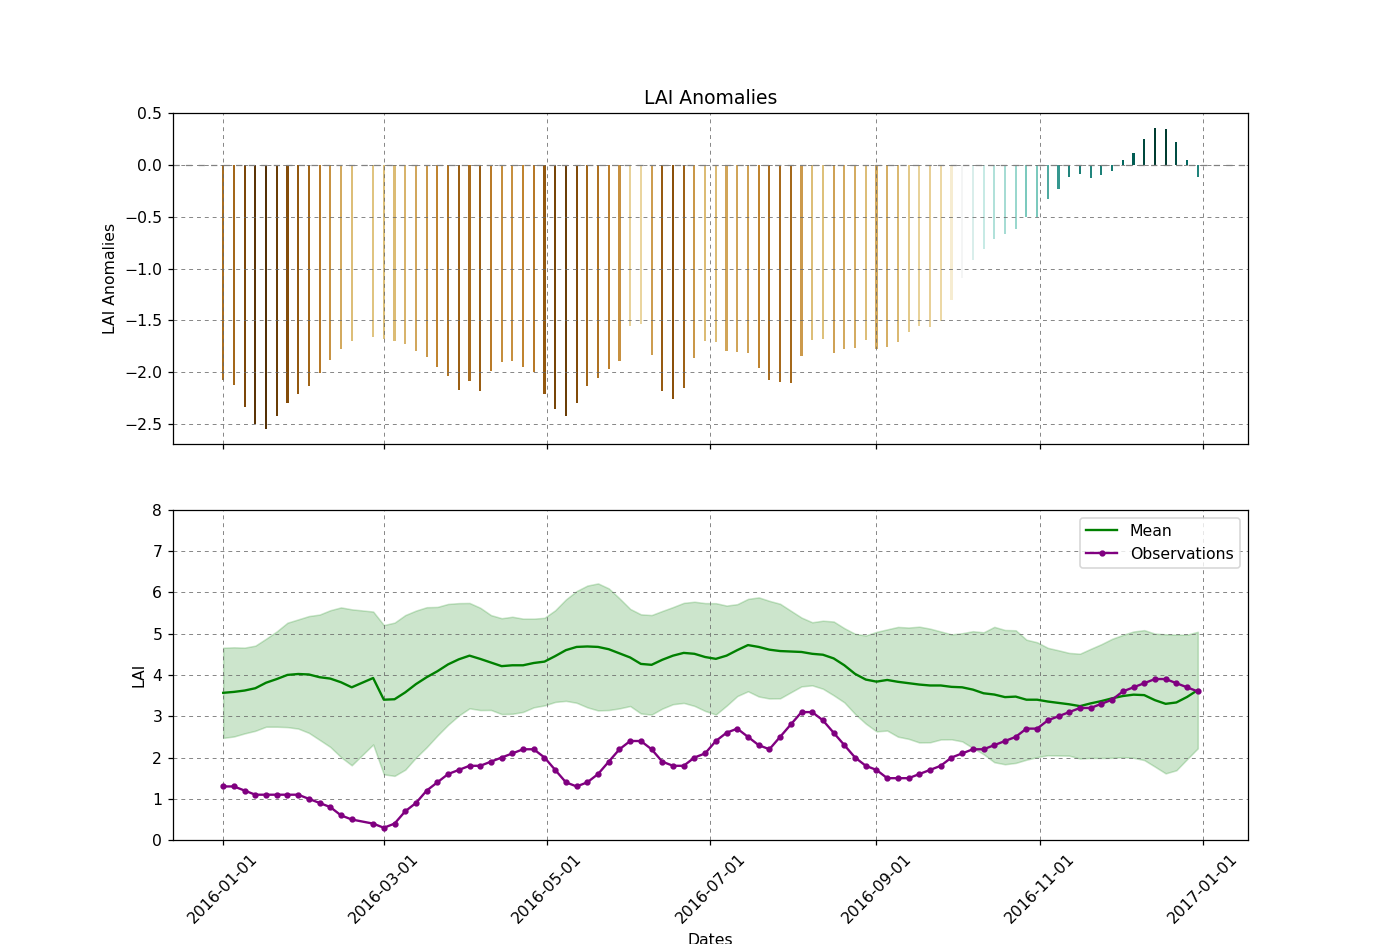

In [20]:
# Get anomalies values for the selected year and the picked lat, lon
data = xr_anomalies.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))\
                .sel(longitude=x, latitude=y, method='nearest')
anomalies = data._Lai_500m.values

# Dates
dates = data.time.values

# Get observation values for the selected year and the picked lat, lon
data = xr_lai.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))\
                .sel(longitude=x, latitude=y, method='nearest')
obs = data.lai.values

# Get mean doy
data = xr_mean.sel(longitude=x, latitude=y, method='nearest')
mean = data._Lai_500m.values[:-1]

# Get std doy
data = xr_std.sel(longitude=x, latitude=y, method='nearest')
std = data._Lai_500m.values[:-1]


# Compute upper and lower bounds for shaded error region
upper_bound = mean + std
lower_bound = mean - std

# Create figure and subplots
fig, (ax, ox) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Normalize data for colormap
norm = Normalize(vmin=anomalies.min(), vmax=anomalies.max())
cmap = plt.get_cmap('BrBG')
colors = [cmap(norm(value)) for value in anomalies]

# Plot anomalies as bar plot
ax.bar(dates, anomalies, color=colors)
ax.axhline(y=0., color='gray', linestyle=(0, (5, 5)), linewidth=0.8)
ax.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.set_ylabel('LAI Anomalies')
ax.set_title('LAI Anomalies')

# Plot mean, observations, and standard deviation range
ox.plot(dates, mean, color='green', label='Mean')
ox.plot(dates, obs, label='Observations', color="purple", marker='.')
ox.fill_between(dates, lower_bound, upper_bound, alpha=0.2, color='green', interpolate=True)

# Formatting
ox.set_xlabel("Dates")
ox.set_ylabel("LAI")
ox.set_ylim(0, 8)
ox.legend()
ox.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)

plt.show()

In [21]:
date_t = a = b = c = ds_p = ds_n = xr_std = xr_mean = ds_sigma_p= xr_anomalies = smooth_point = data_var = None

### Albedo 

In [22]:
# LAI linear.smoothn.descaled
fpath = path + '/timeSeries/MCD43A3.061._Albedo_WSA_Band2.linear.smoothn.0.5.descaled.tif'
arr, dts_obs, opn = gdal_dt(fpath)
xr_albedo = create_xarr(opn, '_Albedo_WSA_Band2', arr, dts_obs)

# LAI detrended
fpath = path + '/timeSeries/MCD43A3.061._Albedo_WSA_Band2.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_albedoDetrended = create_xarr(opn, '_Albedo_WSA_Band2', arr, dts)
arr = dts = saved_opn = None

# LAI climatology mean
fpath = path + "/timeSeries/stats/_Albedo_WSA_Band2_climatology_mean.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_mean = create_xarr(saved_opn, '_Albedo_WSA_Band2', arr, doys)
arr = dts = doys = saved_opn = None

# LAI climatology standard deviation 
fpath = path + "/timeSeries/stats/_Albedo_WSA_Band2_climatology_std.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_std = create_xarr(saved_opn, '_Albedo_WSA_Band2', arr, doys)
arr = dts = doys = saved_opn = None

# calculate sigma # square root of the standard deviation 
ds_sigma_p = np.sqrt(xr_std)

# Calculate error +-
ds_n = xr_mean['_Albedo_WSA_Band2'] - ds_sigma_p
ds_p = xr_mean['_Albedo_WSA_Band2'] + ds_sigma_p

# LAI anomalies
fpath = path + "/timeSeries/stats/_Albedo_WSA_Band2_anomalies.tif"
arr, dts, saved_opn = gdal_dt(fpath)
xr_anomalies = create_xarr(saved_opn, '_Albedo_WSA_Band2', arr, dts)
arr = dts = saved_opn = None

<IPython.core.display.Javascript object>


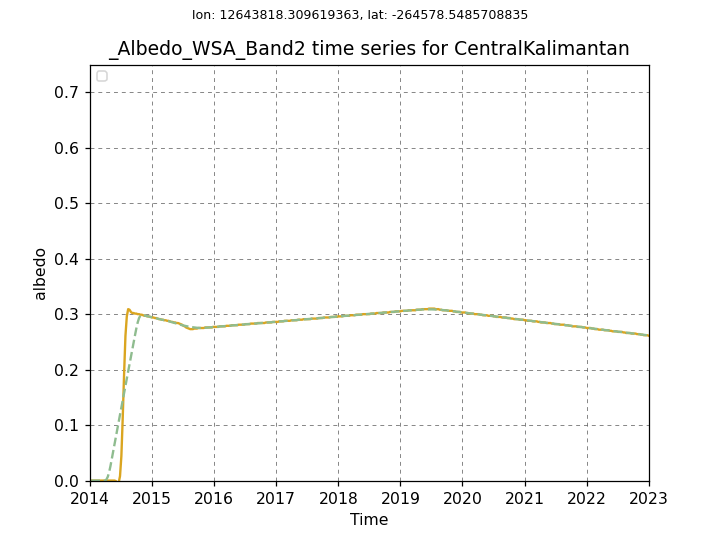

In [23]:
fig, ax = plt.subplots()

ax.plot(xr_albedo['_Albedo_WSA_Band2'].time.values, 
        xr_albedo['_Albedo_WSA_Band2'].sel(latitude=y, longitude=x, method='nearest').data,
       color='goldenrod', label="_Albedo_WSA_Band2 pre-processed")

ax.plot(xr_albedoDetrended['_Albedo_WSA_Band2'].time.values, 
        xr_albedoDetrended['_Albedo_WSA_Band2'].sel(latitude=y, longitude=x, method='nearest').data,
       color='darkseagreen', label="_Albedo_WSA_Band2 detrended",linestyle='--')

ax.set_title(f'_Albedo_WSA_Band2 time series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('albedo')

ax.set_ylim(0,0.75)
ax.set_xlim([datetime(2014, 1, 1), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='upper left', fontsize='small')
# fig.savefig(f'{site}.lai.png', dpi=300)
plt.show()

In [24]:
# 1. albedo raw data 
fpath = glob(path + f'/MCD43A3.061/*/Albedo_WSA_Band2/Albedo_WSA_Band2.vrt')[0]
data = rioxarray.open_rasterio(fpath)
data_point = data.sel(x=x, y=y, method='nearest').values
data_point = data_point.astype(float)
data_point[data_point == 32767] = np.nan 
data_point = data_point*0.001
data_point = data_point[:-2]

# 2. LAI masked + linear interpolation
fpath = glob(path + '/MCD43A3.061/*/Albedo_WSA_Band2/interpolated/MCD43A3.061._Albedo_WSA_Band2.linear.tif')[0]
arr, dts, opn = gdal_dt(fpath)
xr_interpolated = create_xarr(opn, 'albedo', arr, dts)
xr_interpolated = xr_interpolated * 0.001

xr_point = xr_interpolated.sel(longitude=x, latitude=y, method='nearest')

inter_point = xr_point.albedo.values

# 3. albedo smoothed
xr_point = xr_albedo.sel(longitude=x, latitude=y, method='nearest')

smooth_point = xr_point._Albedo_WSA_Band2.values 
time = xr_point.time.values

<IPython.core.display.Javascript object>


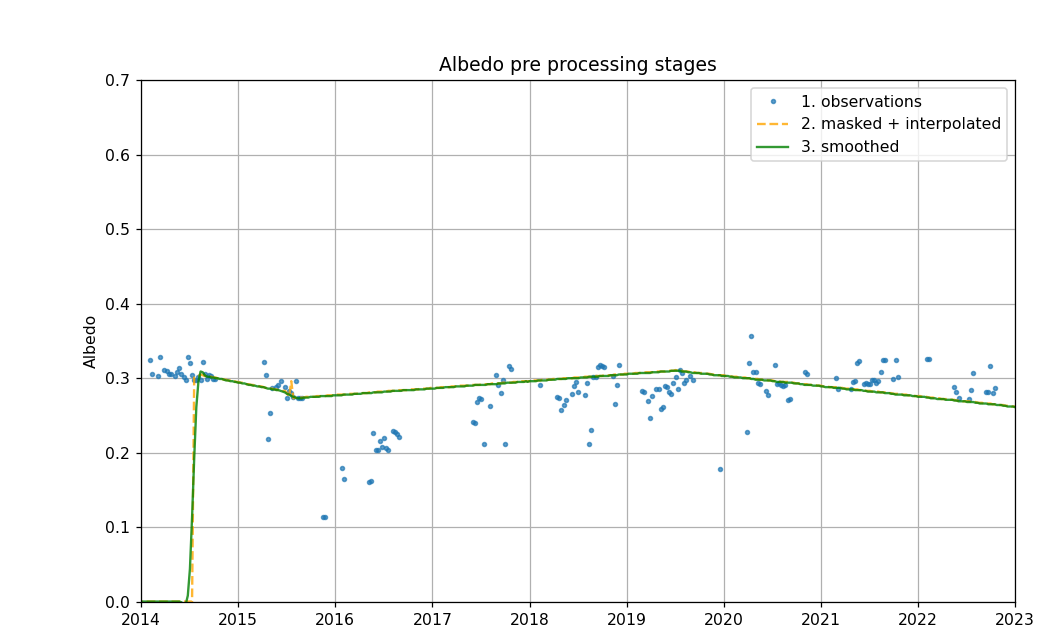

In [25]:
plt.figure(figsize=(10, 6))

# Plot each series
plt.plot(time, data_point, label='1. observations', marker='.', linestyle='', markersize=5, alpha=0.7)
plt.plot(time, inter_point, label='2. masked + interpolated', linestyle='--', color='orange', alpha=0.8)
plt.plot(time, smooth_point, label='3. smoothed', linestyle='-', color='green', alpha=0.8)


xlim_start = np.datetime64('2014-01-01')
xlim_end = np.datetime64('2023-01-01')

# Add titles and labels
plt.title('Albedo pre processing stages')
plt.xlabel('Time')
plt.ylabel('Albedo')
plt.legend()
plt.grid(True)

# Set x-axis limits
plt.xlim(xlim_start, xlim_end)
plt.ylim(0, 0.7)

# Show the plot
plt.show()

# Snow mask 

In [26]:
fpath = glob(f'/wp_data/sites/{site}/MODIS/MCD43A2.061/*/Snow_BRDF_Albedo/Snow_BRDF_Albedo.vrt')[0]
data = rioxarray.open_rasterio(fpath)
snow_pt = data.sel(x=x, y=y, method='nearest').values
snow_pt = snow_pt.astype(float)
snow_pt[snow_pt == 255] = np.nan 
snow_pt = snow_pt[:-2]


masked = np.where(snow_pt == 0, data_point, np.nan)  # Replace values where condition is False

<IPython.core.display.Javascript object>


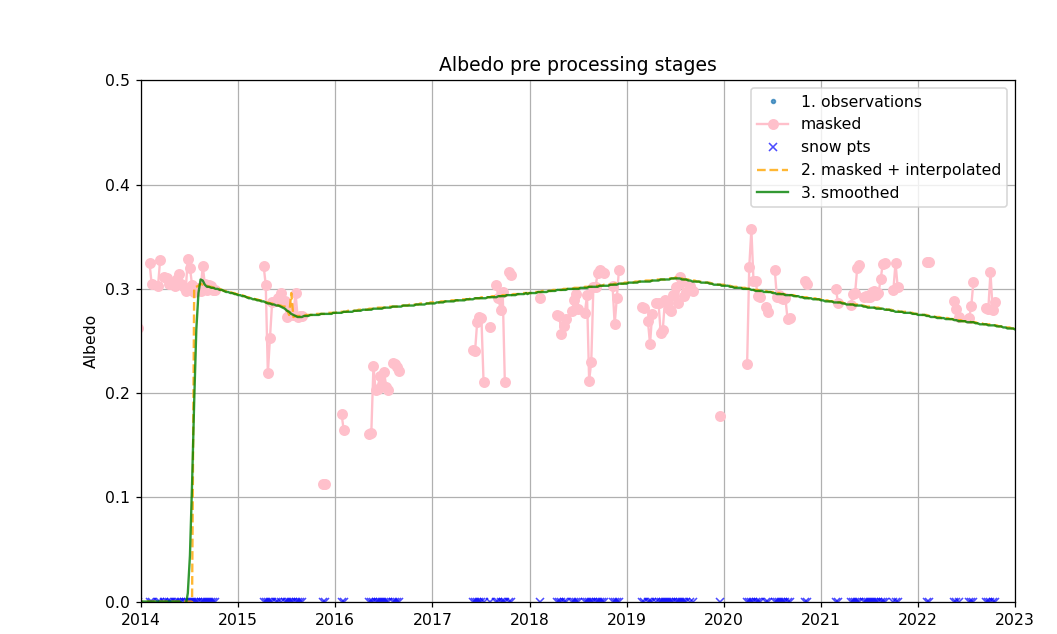

In [27]:
plt.figure(figsize=(10, 6))

# Plot each series
plt.plot(time, data_point, label='1. observations', marker='.', linestyle='', markersize=5, alpha=0.7)
plt.plot(time, masked, label='masked', marker='o', color = 'pink')
plt.plot(time, snow_pt, label='snow pts', marker='x', linestyle='', color='blue', markersize=5, alpha=0.7)
plt.plot(time, inter_point, label='2. masked + interpolated', linestyle='--', color='orange', alpha=0.8)
plt.plot(time, smooth_point, label='3. smoothed', linestyle='-', color='green', alpha=0.8)


xlim_start = np.datetime64('2014-01-01')
xlim_end = np.datetime64('2023-01-01')

# Add titles and labels
plt.title('Albedo pre processing stages')
plt.xlabel('Time')
plt.ylabel('Albedo')
plt.legend()
plt.grid(True)

# Set x-axis limits
plt.xlim(xlim_start, xlim_end)
plt.ylim(0, 0.5)

# Show the plot
plt.show()